In [53]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.spatial import distance_matrix
from matplotlib.patches import Circle

Set a random seed for reproducibility

In [54]:
np.random.seed(42)


Define simulation parameters

In [55]:
N = 10                    # Number of robots
arena_size = 10           # Arena is 10x10 units
Rc = 3.0                  # Communication radius
Rs = 0.5                  # Minimum safety (collision) radius
dt = 0.1                  # Time step
T_max = 100               # Number of simulation steps

Initialize robot positions randomly

In [56]:
positions = np.random.rand(N, 2) * arena_size

Store trajectory history for visualization

In [57]:
trajectories = [positions.copy()]

Step 2: Create initial communication graph and visualize

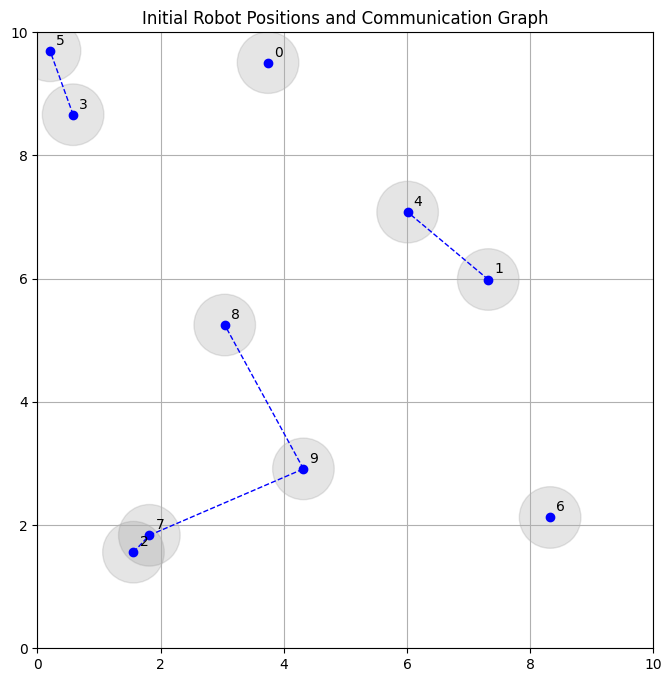

In [58]:
G = compute_graph(positions, Rc)
plot_robots(positions, G, "Initial Robot Positions and Communication Graph")


Step 3: Define Goals and Control Law

In [59]:
goal_positions = np.random.rand(N, 2) * arena_size

# Control parameters
k_goal = 1.0     # Gain for attraction toward goal
k_avoid = 2.0    # Gain for repulsion from close neighbors
v_max = 1.0      # Max velocity magnitude

# Control function: computes control input for robot i
def compute_control(i, positions, goal_positions, Rc, Rs):
    pos_i = positions[i]
    u = np.zeros(2)

    # 1. Goal attraction
    error = goal_positions[i] - pos_i
    u += k_goal * error

    # 2. Repulsion from neighbors within Rs
    for j in range(N):
        if i == j:
            continue
        dist = np.linalg.norm(pos_i - positions[j])
        if dist < Rs and dist > 1e-2:  # avoid divide by zero
            repulsion = (pos_i - positions[j]) / dist
            u += k_avoid * (1.0 / dist - 1.0 / Rs) * repulsion

    # 3. Clip to max speed
    speed = np.linalg.norm(u)
    if speed > v_max:
        u = u / speed * v_max

    return u


Simulate Movement Over Time

In [60]:
# Reset positions
positions = trajectories[0].copy()
trajectories = [positions.copy()]

# Simulate with connectivity-aware control
for t in range(T_max):
    new_positions = positions.copy()

    for i in range(N):
        u_i = compute_control_with_connectivity(i, positions, goal_positions, Rc, Rs)
        new_positions[i] += u_i * dt

    positions = new_positions
    trajectories.append(positions.copy())


Plot Results After Simulation

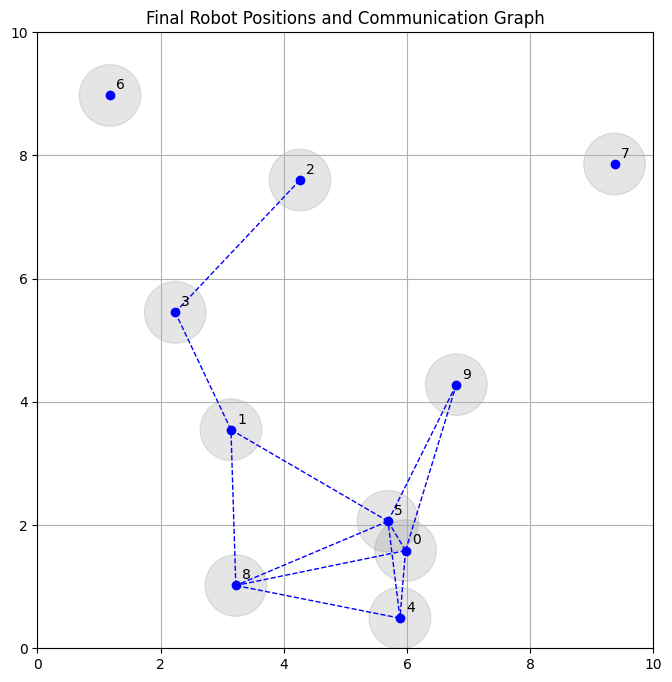

In [61]:
# Plot final communication graph
G_final = compute_graph(positions, Rc)
plot_robots(positions, G_final, "Final Robot Positions and Communication Graph")

Plot Robot Trajectories Over Time

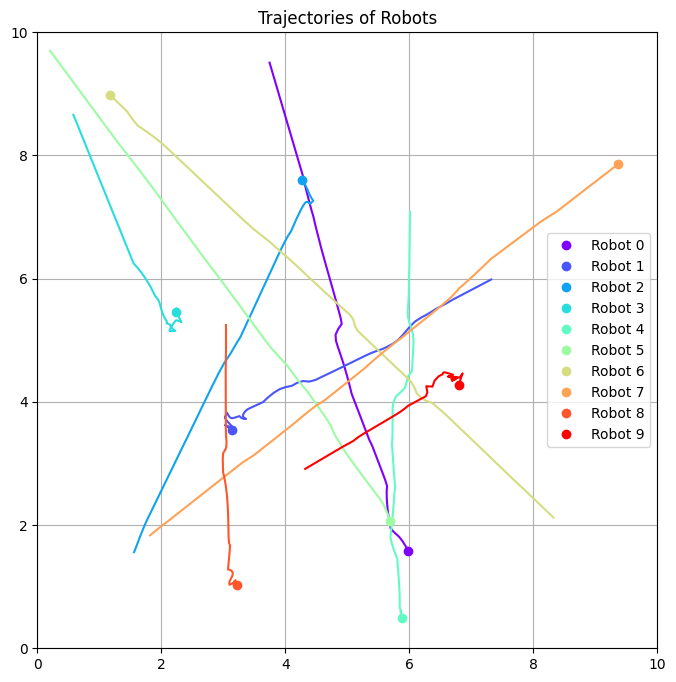

In [62]:
# Plot robot trajectories
import matplotlib.cm as cm

def plot_trajectories(trajectories):
    plt.figure(figsize=(8, 8))
    plt.xlim(0, arena_size)
    plt.ylim(0, arena_size)
    plt.title("Trajectories of Robots")
    colors = cm.rainbow(np.linspace(0, 1, N))

    for i in range(N):
        traj = np.array([p[i] for p in trajectories])
        plt.plot(traj[:, 0], traj[:, 1], color=colors[i])
        plt.plot(traj[-1, 0], traj[-1, 1], 'o', color=colors[i], label=f'Robot {i}')
    
    plt.legend()
    plt.grid(True)
    plt.show()

plot_trajectories(trajectories)


Step 5: Enhance control law to preserve communication with current neighbors


In [63]:
k_connect = 1.5   # Gain for communication-preserving term

# Modified control function to add connectivity preservation
def compute_control_with_connectivity(i, positions, goal_positions, Rc, Rs):
    pos_i = positions[i]
    u = np.zeros(2)

    # Goal attraction
    error = goal_positions[i] - pos_i
    u += k_goal * error

    # Collision avoidance
    for j in range(N):
        if i == j:
            continue
        dist = np.linalg.norm(pos_i - positions[j])
        if dist < Rs and dist > 1e-2:
            repulsion = (pos_i - positions[j]) / dist
            u += k_avoid * (1.0 / dist - 1.0 / Rs) * repulsion

    # Communication preservation with current neighbors
    for j in range(N):
        if i == j:
            continue
        dist = np.linalg.norm(pos_i - positions[j])
        if dist <= Rc and dist >= Rc * 0.9:  # approaching edge of comm range
            attraction = (positions[j] - pos_i) / dist
            u += k_connect * (dist - Rc * 0.9) * attraction  # soft pull

    # Clip to max speed
    speed = np.linalg.norm(u)
    if speed > v_max:
        u = u / speed * v_max

    return u


Graph and Plot Helper Functions

In [64]:
# Helper function to compute communication graph
def compute_graph(positions, Rc):
    dist = distance_matrix(positions, positions)
    G = nx.Graph()
    for i in range(N):
        for j in range(i + 1, N):
            if dist[i, j] <= Rc:
                G.add_edge(i, j)
    return G

# Helper function to plot robot positions and communication graph
def plot_robots(pos, graph, title=""):
    plt.figure(figsize=(8, 8))
    plt.xlim(0, arena_size)
    plt.ylim(0, arena_size)
    plt.gca().set_aspect('equal')
    plt.title(title)

    for i, p in enumerate(pos):
        plt.gca().add_patch(Circle(p, Rs, color='gray', alpha=0.2))  # Safety zone
        plt.plot(p[0], p[1], 'bo')
        plt.text(p[0] + 0.1, p[1] + 0.1, str(i), fontsize=10)
    
    for (i, j) in graph.edges:
        p1, p2 = pos[i], pos[j]
        plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'b--', linewidth=1)

    plt.grid(True)
    plt.show()
